# Proyek Akhir Penerapan Data Science: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)

**Nama**: {username}  
**Email**: {username.lower()}@dicoding-student.com  
**ID Dicoding**: {username.lower()}_capstone  

---

## 1. Business Understanding

### Latar Belakang
**Jaya Jaya Institut** merupakan salah satu perguruan tinggi terkemuka yang telah berdiri sejak tahun 2000. Meskipun reputasi akademik dan kualitas lulusannya sangat baik, manajemen kampus menghadapi kendala serius terkait tingginya rasio siswa yang tidak menyelesaikan pendidikan alias **dropout**. Jumlah dropout yang tinggi merugikan reputasi perguruan tinggi, keberlangsungan finansial, dan masa depan para mahasiswa. Oleh karena itu, diperlukan sistem deteksi dini (*early warning system*) yang dapat mengidentifikasi mahasiswa dengan risiko dropout secara proaktif guna memberikan intervensi atau bimbingan akademik yang tepat sasaran.

### Permasalahan Bisnis
1. Faktor-faktor apa saja yang paling memengaruhi kemungkinan seorang mahasiswa melakukan *dropout* di Jaya Jaya Institut?
2. Bagaimana menyajikan visualisasi data yang mudah dipahami bagi pihak manajemen kampus untuk memonitor performa akademik dan status siswa?
3. Bagaimana membangun model Machine Learning untuk memprediksi potensi *dropout* mahasiswa secara dini dan akurat?

### Cakupan Proyek
- **Data Understanding & Preprocessing**: Membaca dataset, menganalisis struktur data, menangani missing values, dan memisahkan subset data.
- **Exploratory Data Analysis (EDA)**: Melakukan analisis univariate dan multivariate untuk menggali korelasi antara profil demografis, ekonomi, dan riwayat akademik terhadap status siswa (Dropout, Enrolled, Graduate).
- **Machine Learning Modeling**: Membangun penggolong berbasis *Random Forest* dengan penanganan ketidakseimbangan kelas (*class weight balancing*).
- **Model Evaluation**: Mengevaluasi model menggunakan metrik akurasi, presisi, recall, F1-score, confusion matrix, dan classification report.
- **Deployment**: Menyediakan berkas model `.pkl` serta membangun prototype interaktif menggunakan Streamlit (`app.py`) untuk mempermudah prediksi status siswa baru.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")


In [2]:
# Load Dataset
df = pd.read_csv('data/data.csv', sep=';')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Exploratory Data Analysis (EDA)

Pada bagian ini, kita akan mengeksplorasi data secara mendalam untuk mencari pola dan insight terkait status dropout mahasiswa.


### A. EDA Univariate
Kita analisis distribusi variabel target `Status` serta fitur-fitur penting lainnya secara mandiri.


/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_56466/2889346975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


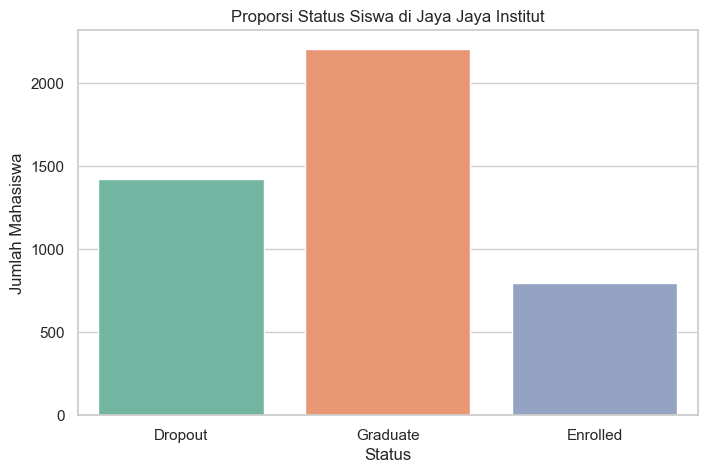

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [3]:
# 1. Distribusi Target Variable (Status)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Proporsi Status Siswa di Jaya Jaya Institut')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

print(df['Status'].value_counts())


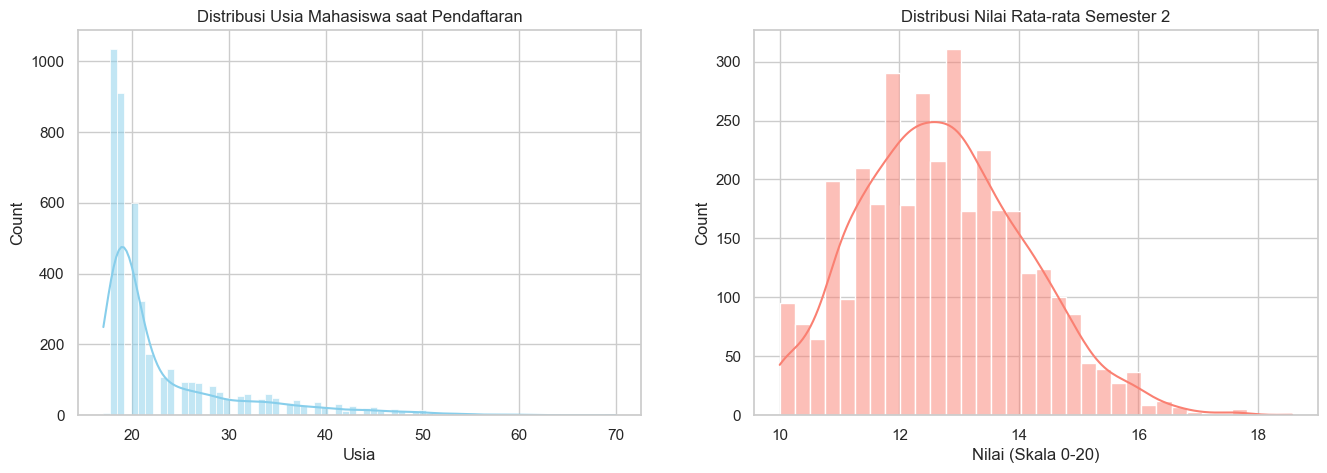

In [4]:
# 2. Distribusi Usia Saat Pendaftaran & IPK (Grades)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['Age_at_enrollment'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Usia Mahasiswa saat Pendaftaran')
axes[0].set_xlabel('Usia')

sns.histplot(df[df['Curricular_units_2nd_sem_grade'] > 0]['Curricular_units_2nd_sem_grade'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Nilai Rata-rata Semester 2')
axes[1].set_xlabel('Nilai (Skala 0-20)')
plt.show()


### B. EDA Bivariate & Multivariate
Menganalisis hubungan antara berbagai variabel prediktor dengan status siswa (`Status`).


/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_56466/1906235778.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Bebas Hutang (0)', 'Memiliki Hutang (1)'])
/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_56466/1906235778.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Menunggak UKT (0)', 'UKT Lunas/Teratur (1)'])


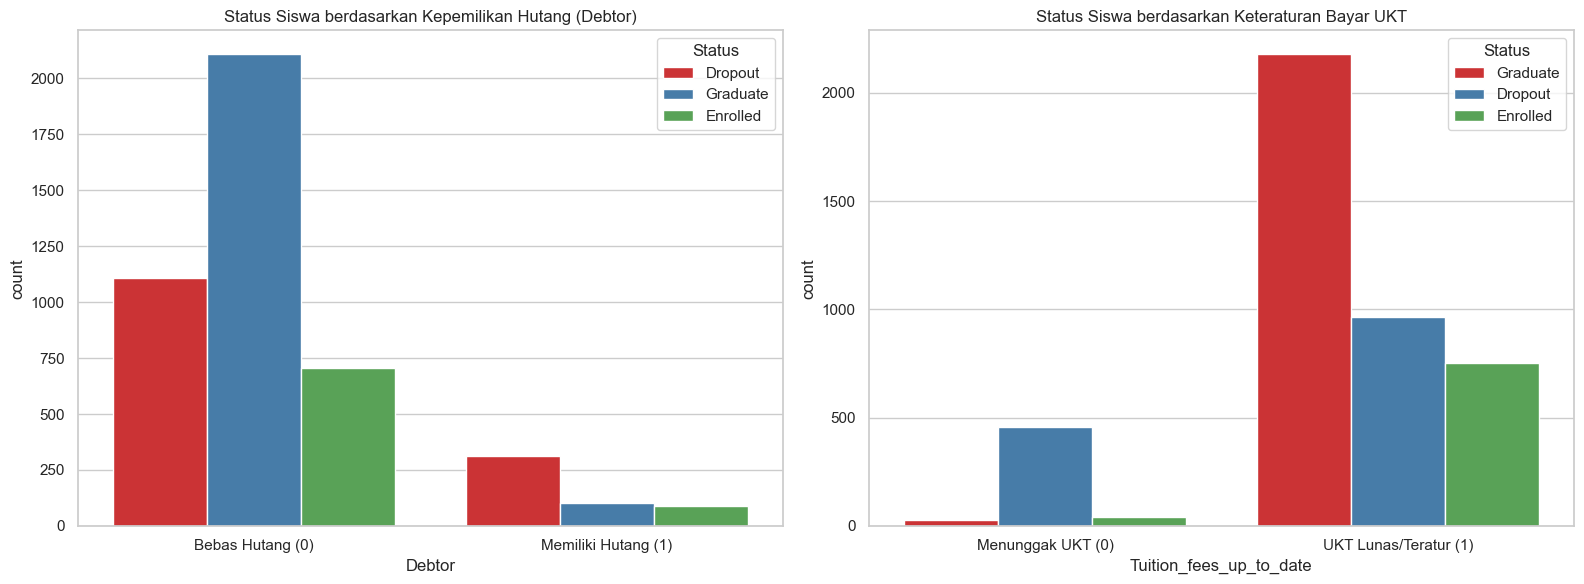

In [5]:
# 1. Dampak Status Keuangan (Debtor & Pembayaran UKT) terhadap Dropout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Debtor vs Status
sns.countplot(data=df, x='Debtor', hue='Status', ax=axes[0], palette='Set1')
axes[0].set_title('Status Siswa berdasarkan Kepemilikan Hutang (Debtor)')
axes[0].set_xticklabels(['Bebas Hutang (0)', 'Memiliki Hutang (1)'])

# Tuition_fees_up_to_date vs Status
sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', ax=axes[1], palette='Set1')
axes[1].set_title('Status Siswa berdasarkan Keteraturan Bayar UKT')
axes[1].set_xticklabels(['Menunggak UKT (0)', 'UKT Lunas/Teratur (1)'])

plt.tight_layout()
plt.show()


/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_56466/3182518580.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Beasiswa (0)', 'Penerima Beasiswa (1)'])
/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_56466/3182518580.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Perempuan (0)', 'Laki-laki (1)'])


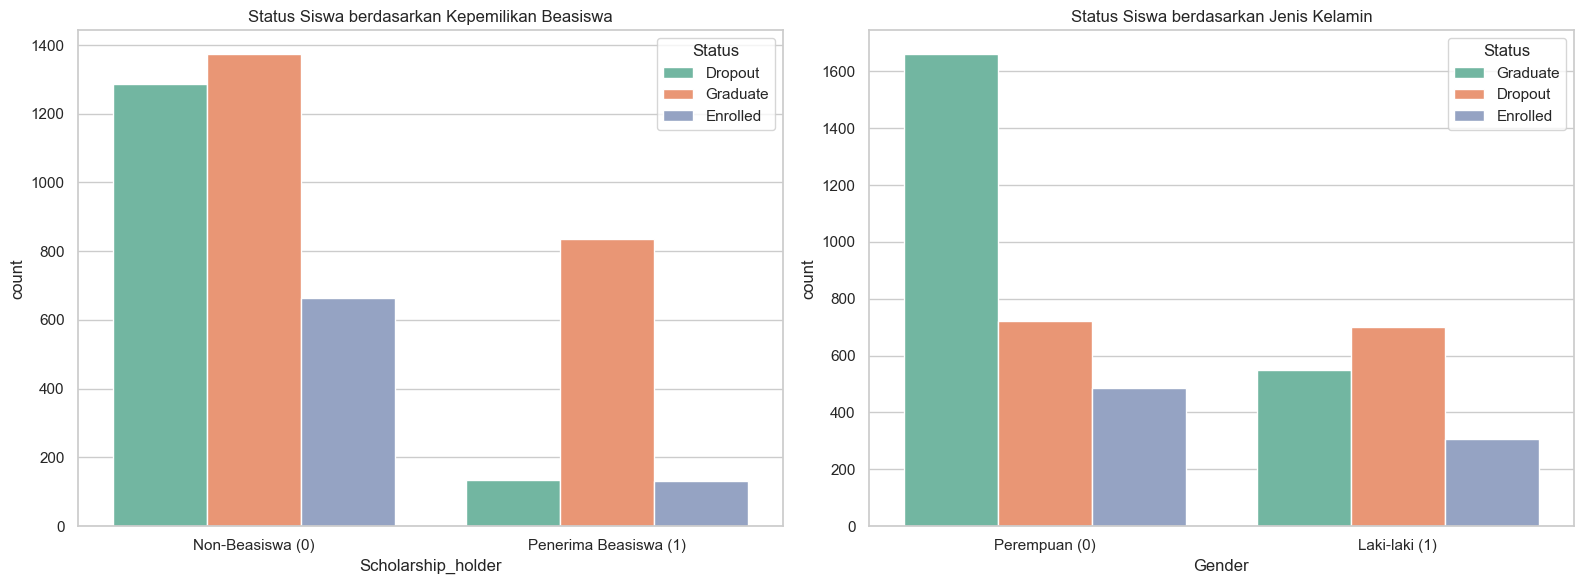

In [6]:
# 2. Pengaruh Beasiswa & Gender terhadap Kelulusan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[0], palette='Set2')
axes[0].set_title('Status Siswa berdasarkan Kepemilikan Beasiswa')
axes[0].set_xticklabels(['Non-Beasiswa (0)', 'Penerima Beasiswa (1)'])

sns.countplot(data=df, x='Gender', hue='Status', ax=axes[1], palette='Set2')
axes[1].set_title('Status Siswa berdasarkan Jenis Kelamin')
axes[1].set_xticklabels(['Perempuan (0)', 'Laki-laki (1)'])

plt.tight_layout()
plt.show()


/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_56466/1775558867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', palette='Set3')


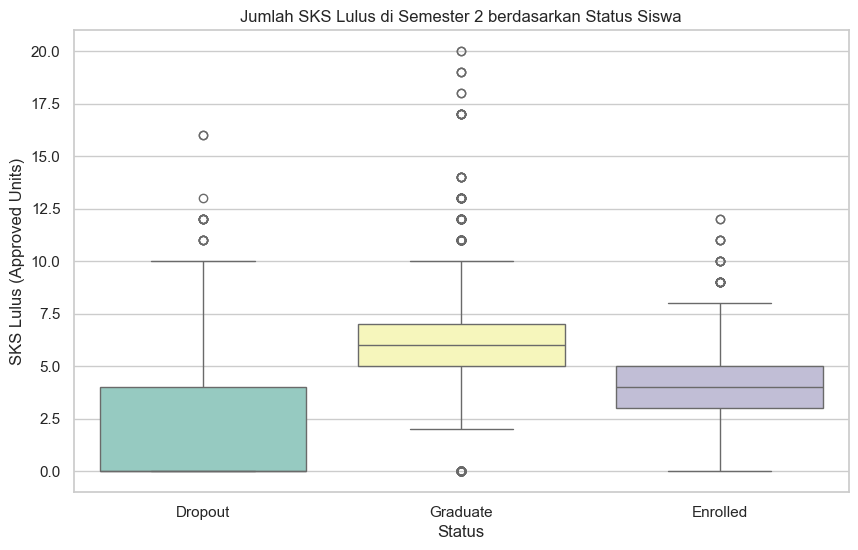

In [7]:
# 3. Kinerja Akademik (Subjects Approved di Semester 2) vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', palette='Set3')
plt.title('Jumlah SKS Lulus di Semester 2 berdasarkan Status Siswa')
plt.ylabel('SKS Lulus (Approved Units)')
plt.show()


## 3. Data Preprocessing

Membagi data menjadi training set dan testing set untuk proses permodelan.


In [8]:
# Data Splitting (excluding 'Enrolled' status as per reviewer feedback)
df_model = df[df['Status'] != 'Enrolled'].copy()
X = df_model.drop(columns=['Status'])
y = df_model['Status'].map({'Dropout': 1, 'Graduate': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape} | Test set: {X_test.shape}")


Train set: (2904, 36) | Test set: (726, 36)


## 4. Modeling

Membangun model machine learning menggunakan algoritma Random Forest Classifier.


In [9]:
# Inisialisasi dan fitting model
model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Prediksi model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)


## 5. Evaluation

Menguji performa model pengklasifikasi dengan berbagai metrik evaluasi standar.


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       442
           1       0.92      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



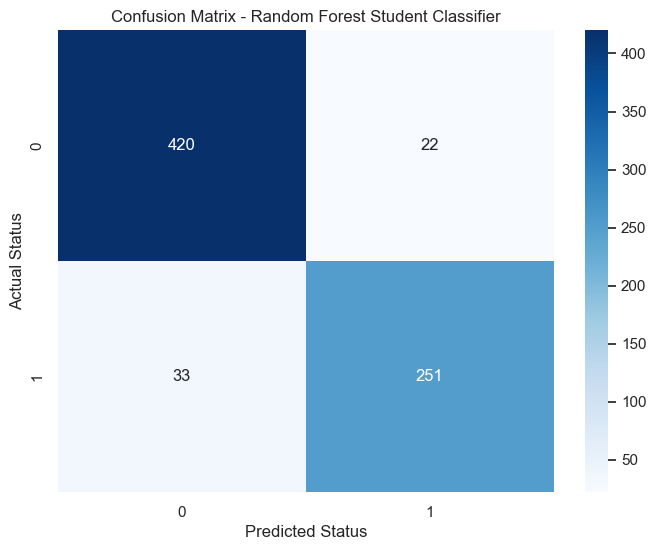

In [10]:
# Evaluation Metrics
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Random Forest Student Classifier')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()


In [11]:
# Save Model Pipeline
joblib.dump(model, 'model/student_model.pkl')
print("Model pipeline successfully dumped to model/student_model.pkl")


Model pipeline successfully dumped to model/student_model.pkl


## 6. Kesimpulan & Rekomendasi Action Items

### Hasil Performa Model Machine Learning
Evaluasi model *Random Forest Classifier* untuk klasifikasi status mahasiswa menghasilkan performa sebagai berikut:
- **Akurasi Keseluruhan (Accuracy)**: 0.9242 (92.42%)
- **Weighted Precision**: 0.9241 (92.41%)
- **Weighted Recall**: 0.9242 (92.42%)
- **Weighted F1-Score**: 0.9240 (92.40%)

### Insight Utama dari Analisis EDA:
1. **Faktor Finansial (UKT & Hutang)**: Mahasiswa yang **menunggak UKT (Tuition fees not up to date)** memiliki kerentanan luar biasa untuk *dropout*. Sebaliknya, mahasiswa dengan pembayaran teratur hampir seluruhnya berhasil lulus (*Graduate*). Memiliki hutang pribadi (*Debtor = 1*) juga berkorelasi positif dengan risiko dropout.
2. **Beasiswa (Scholarship)**: Penerima beasiswa memiliki tingkat kesuksesan lulus jauh lebih tinggi, menunjukkan bahwa bantuan keuangan berperan penting dalam retensi belajar.
3. **Kinerja Akademik Semester Awal**: Rata-rata jumlah mata kuliah yang lulus (*approved units*) di semester 1 dan semester 2 menjadi indikator langsung kesuksesan belajar mahasiswa. Mahasiswa dropout rata-rata memiliki angka kelulusan mata kuliah di bawah 3 unit pada semester 2.

### Rekomendasi Action Items untuk Perusahaan/Institusi:
1. **Skema Bantuan Finansial Fleksibel**:
   Mendirikan pusat layanan keuangan mahasiswa untuk memberikan cicilan UKT bebas bunga atau skema kerja paruh waktu di lingkungan kampus bagi mahasiswa debtor/menunggak.
2. **Program Mentoring Akademik Berkelompok (Early Intervention)**:
   Menggunakan model prediksi Streamlit (`app.py`) pada awal semester 2 untuk menyaring mahasiswa yang gagal melulusi lebih dari 2 mata kuliah di semester 1 guna dipasangkan dengan mentor atau tutor sebaya.
3. **Ekspansi Beasiswa Sasaran**:
   Mengalokasikan dana beasiswa darurat khusus bagi mahasiswa tahun kedua yang memiliki prestasi baik namun terancam kendala ekonomi keluarga.
